z1 = 0.06666666666666672
z2 = 0.5666666666666667
C1 and C2 = 4.894736842105263 1.105263157894737


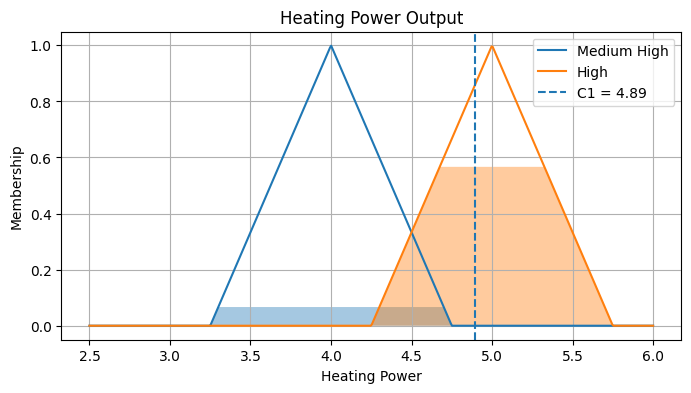

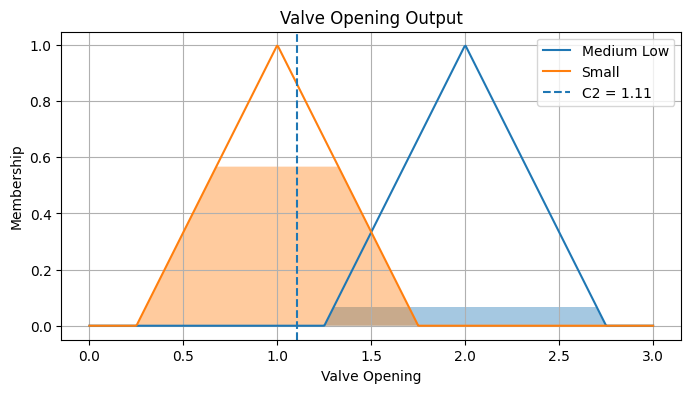

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class myFuzzySet:
    def __init__(self, a, b, c):
        self.a = a
        self.b = b
        self.c = c

    def membership(self, x):
        if x <= self.a or x >= self.c:
            return 0
        elif x <= self.b:
            return (x - self.a) / (self.b - self.a)
        else:
            return (self.c - x) / (self.c - self.b)

    def area(self):
        return (self.c - self.b)

temperature_below_average = myFuzzySet(15, 30, 45)
temperature_low = myFuzzySet(-5, 10, 25)
pressure_below_average = myFuzzySet(1.25, 2, 2.75)
pressure_low = myFuzzySet(0.25, 1, 1.75)
heating_power_medium_high = myFuzzySet(3.25, 4, 4.75)
heating_power_high = myFuzzySet(4.25, 5, 5.75)
valve_opening_medium_low = myFuzzySet(1.25, 2, 2.75)
valve_opening_small = myFuzzySet(0.25, 1, 1.75)

temperature_input = 16.5
pressure_input = 1.3

z1 = min(
    temperature_below_average.membership(temperature_input),
    pressure_below_average.membership(pressure_input)
)

z2 = min(
    temperature_low.membership(temperature_input),
    pressure_low.membership(pressure_input)
)
print("z1 =", z1)
print("z2 =", z2)


c1num = (z1 * heating_power_medium_high.area() * heating_power_medium_high.b) + \
        (z2 * heating_power_high.area() * heating_power_high.b)

c2num = (z1 * valve_opening_medium_low.area() * valve_opening_medium_low.b) + \
        (z2 * valve_opening_small.area() * valve_opening_small.b)

c1den = (z1 * heating_power_medium_high.area()) + \
        (z2 * heating_power_high.area())

c2den = (z1 * valve_opening_medium_low.area()) + \
        (z2 * valve_opening_small.area())

c1 = c1num / c1den
c2 = c2num / c2den
print("C1 and C2 =", c1,c2)

x_hp = np.linspace(2.5, 6, 500)
mh = np.array([heating_power_medium_high.membership(x) for x in x_hp])
h = np.array([heating_power_high.membership(x) for x in x_hp])

plt.figure(figsize=(8,4))
plt.plot(x_hp, mh, label="Medium High")
plt.plot(x_hp, h, label="High")
plt.fill_between(x_hp, 0, np.minimum(mh, z1), alpha=0.4)
plt.fill_between(x_hp, 0, np.minimum(h, z2), alpha=0.4)
plt.axvline(c1, linestyle="--", label=f"C1 = {c1:.2f}")
plt.xlabel("Heating Power")
plt.ylabel("Membership")
plt.title("Heating Power Output")
plt.legend()
plt.grid(True)
plt.show()

x_vo = np.linspace(0, 3, 500)
ml = np.array([valve_opening_medium_low.membership(x) for x in x_vo])
s = np.array([valve_opening_small.membership(x) for x in x_vo])

plt.figure(figsize=(8,4))
plt.plot(x_vo, ml, label="Medium Low")
plt.plot(x_vo, s, label="Small")
plt.fill_between(x_vo, 0, np.minimum(ml, z1), alpha=0.4)
plt.fill_between(x_vo, 0, np.minimum(s, z2), alpha=0.4)
plt.axvline(c2, linestyle="--", label=f"C2 = {c2:.2f}")
plt.xlabel("Valve Opening")
plt.ylabel("Membership")
plt.title("Valve Opening Output")
plt.legend()
plt.grid(True)
plt.show()


z1 = 0.6000000000000001
z2 = 0.24999999999999972
C1 and C2 = 4.044117647058823 1.4558823529411768


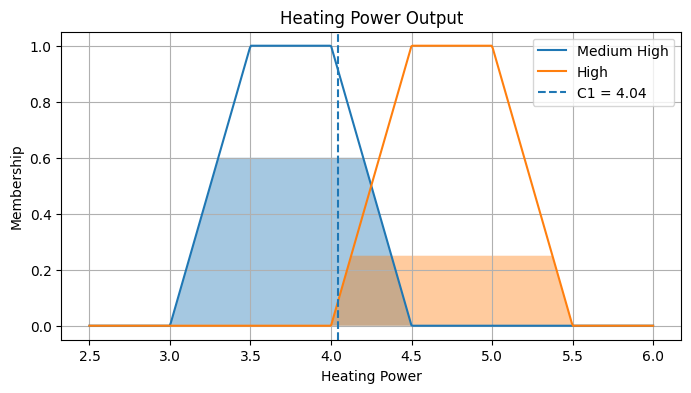

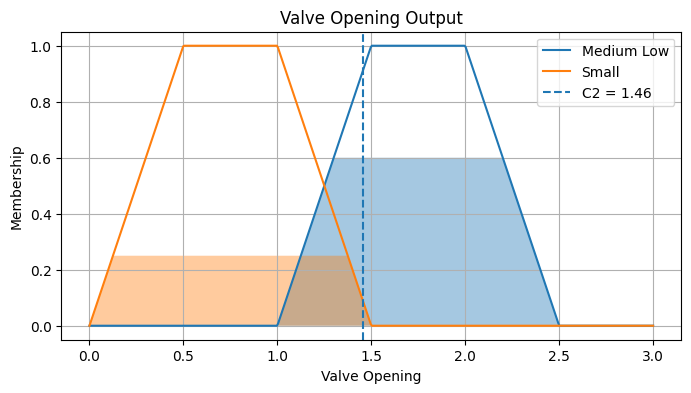

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class myTrapezoidalFuzzySet:
    def __init__(self, a, b, c, d):
        self.a = a
        self.b = b
        self.c = c
        self.d = d

    def membership(self, x):
        if x <= self.a or x >= self.d:
            return 0
        elif self.a < x <= self.b:
            return (x - self.a) / (self.b - self.a)
        elif self.b < x <= self.c:
            return 1
        else:
            return (self.d - x) / (self.d - self.c)

    def area(self):
        return (self.d - self.a + self.c - self.b) / 2


temperature_below_average = myTrapezoidalFuzzySet(10, 20, 30, 40)
temperature_low = myTrapezoidalFuzzySet(-10, 0, 10, 20)

pressure_below_average = myTrapezoidalFuzzySet(1.0, 1.5, 2.0, 2.5)
pressure_low = myTrapezoidalFuzzySet(0.2, 0.6, 1.0, 1.4)

heating_power_medium_high = myTrapezoidalFuzzySet(3.0, 3.5, 4.0, 4.5)
heating_power_high = myTrapezoidalFuzzySet(4.0, 4.5, 5.0, 5.5)

valve_opening_medium_low = myTrapezoidalFuzzySet(1.0, 1.5, 2.0, 2.5)
valve_opening_small = myTrapezoidalFuzzySet(0.0, 0.5, 1.0, 1.5)

temperature_input = 16.5
pressure_input = 1.3

z1 = min(
    temperature_below_average.membership(temperature_input),
    pressure_below_average.membership(pressure_input)
)

z2 = min(
    temperature_low.membership(temperature_input),
    pressure_low.membership(pressure_input)
)

print("z1 =", z1)
print("z2 =", z2)

c1num = (z1 * heating_power_medium_high.area() *
         (heating_power_medium_high.b + heating_power_medium_high.c) / 2) + \
        (z2 * heating_power_high.area() *
         (heating_power_high.b + heating_power_high.c) / 2)

c1den = (z1 * heating_power_medium_high.area()) + \
        (z2 * heating_power_high.area())

c1 = c1num / c1den

c2num = (z1 * valve_opening_medium_low.area() *
         (valve_opening_medium_low.b + valve_opening_medium_low.c) / 2) + \
        (z2 * valve_opening_small.area() *
         (valve_opening_small.b + valve_opening_small.c) / 2)

c2den = (z1 * valve_opening_medium_low.area()) + \
        (z2 * valve_opening_small.area())

c2 = c2num / c2den

print("C1 and C2 =", c1, c2)

x_hp = np.linspace(2.5, 6, 500)
mh = np.array([heating_power_medium_high.membership(x) for x in x_hp])
h = np.array([heating_power_high.membership(x) for x in x_hp])

plt.figure(figsize=(8,4))
plt.plot(x_hp, mh, label="Medium High")
plt.plot(x_hp, h, label="High")
plt.fill_between(x_hp, 0, np.minimum(mh, z1), alpha=0.4)
plt.fill_between(x_hp, 0, np.minimum(h, z2), alpha=0.4)
plt.axvline(c1, linestyle="--", label=f"C1 = {c1:.2f}")
plt.xlabel("Heating Power")
plt.ylabel("Membership")
plt.title("Heating Power Output")
plt.legend()
plt.grid(True)
plt.show()

x_vo = np.linspace(0, 3, 500)
ml = np.array([valve_opening_medium_low.membership(x) for x in x_vo])
s = np.array([valve_opening_small.membership(x) for x in x_vo])

plt.figure(figsize=(8,4))
plt.plot(x_vo, ml, label="Medium Low")
plt.plot(x_vo, s, label="Small")
plt.fill_between(x_vo, 0, np.minimum(ml, z1), alpha=0.4)
plt.fill_between(x_vo, 0, np.minimum(s, z2), alpha=0.4)
plt.axvline(c2, linestyle="--", label=f"C2 = {c2:.2f}")
plt.xlabel("Valve Opening")
plt.ylabel("Membership")
plt.title("Valve Opening Output")
plt.legend()
plt.grid(True)
plt.show()


z1 =  0.0657285286165305
z2 =  0.360447788597821
c1:4.845771512959338
c2:1.0


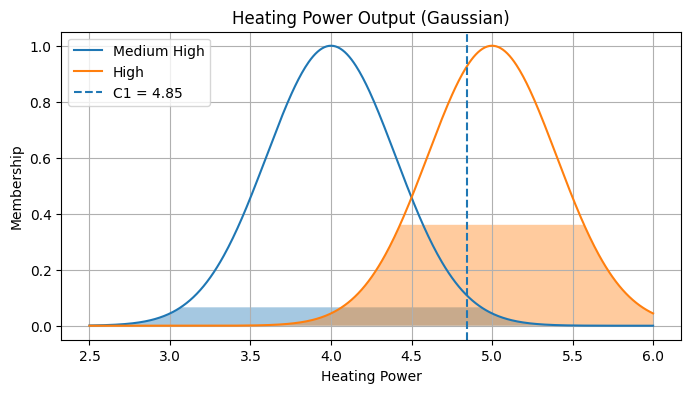

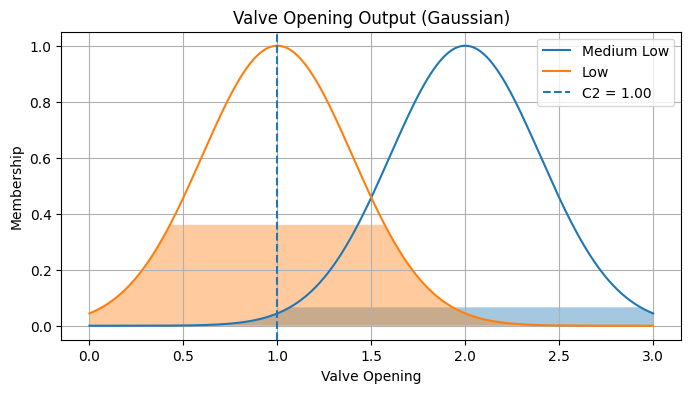

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class myGaussianFuzzySet:
  def __init__(self, c, sigma):
    self.c = c
    self.sigma = sigma

  def membership(self, x):
    return np.exp(-((x -self.c)**2) / (2*self.sigma**2))

  def area(self):
    return self.sigma * np.sqrt(2 * np.pi)

temperature_below_average = myGaussianFuzzySet(30, 7)
temperature_low = myGaussianFuzzySet(10, 7)

pressure_below_average = myGaussianFuzzySet(2.0, 0.3)
pressure_low = myGaussianFuzzySet(1.0, 0.3)

heating_power_medium_high = myGaussianFuzzySet(4.0, 0.4)
heating_power_high = myGaussianFuzzySet(5.0, 0.4)

valve_opening_medium_low = myGaussianFuzzySet(2.0, 0.4)
valve_opening_low = myGaussianFuzzySet(1.0, 0.4)

temperature_input = 20.0
pressure_input = 1.3

z1 = min(temperature_below_average.membership(temperature_input),pressure_below_average.membership(pressure_input))

z2 = min(temperature_low.membership(temperature_input), pressure_low.membership(pressure_input))

print("z1 = ", z1)
print("z2 = ", z2)

#defuzzification

c1num = (
    z1 * heating_power_medium_high.area()*heating_power_medium_high.c +
    z2 * heating_power_high.area()* heating_power_high.c
)
c2num = (
    z1 * valve_opening_medium_low.area()*valve_opening_medium_low.c + z2 * valve_opening_low.area()*valve_opening_low.c
)

c1den = (
    z1*heating_power_medium_high.area()+z2*heating_power_high.area()
)
c2den = (
    z1*valve_opening_medium_low.area()+z2*valve_opening_low.area()
)

c1 = c1num/c1den
c2 = c2num/c2num

print(f"c1:{c1}")
print(f"c2:{c2}")

x_hp = np.linspace(2.5, 6, 500)
mh = np.array([heating_power_medium_high.membership(x) for x in x_hp])
h = np.array([heating_power_high.membership(x) for x in x_hp])

plt.figure(figsize=(8,4))
plt.plot(x_hp, mh, label="Medium High")
plt.plot(x_hp, h, label="High")
plt.fill_between(x_hp, 0, np.minimum(mh, z1), alpha=0.4)
plt.fill_between(x_hp, 0, np.minimum(h, z2), alpha=0.4)
plt.axvline(c1, linestyle="--", label=f"C1 = {c1:.2f}")
plt.xlabel("Heating Power")
plt.ylabel("Membership")
plt.title("Heating Power Output (Gaussian)")
plt.legend()
plt.grid(True)
plt.show()


x_vo = np.linspace(0, 3, 500)
ml = np.array([valve_opening_medium_low.membership(x) for x in x_vo])
l = np.array([valve_opening_low.membership(x) for x in x_vo])

plt.figure(figsize=(8,4))
plt.plot(x_vo, ml, label="Medium Low")
plt.plot(x_vo, l, label="Low")
plt.fill_between(x_vo, 0, np.minimum(ml, z1), alpha=0.4)
plt.fill_between(x_vo, 0, np.minimum(l, z2), alpha=0.4)
plt.axvline(c2, linestyle="--", label=f"C2 = {c2:.2f}")
plt.xlabel("Valve Opening")
plt.ylabel("Membership")
plt.title("Valve Opening Output (Gaussian)")
plt.legend()
plt.grid(True)
plt.show()

